## **Foundations of Deep Learning**
Project Name: **🌸 Flower Classification**

By: **Aarohi Mistry** | Matricola: **925352**

Date: 14/07/2026

#### Import Libraries, seeds and check GPU

In [ ]:
import random
import pathlib
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_recall_fscore_support
)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
# Fix random seeds to ensure reproducible experiments
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
GPU available: True


#### Configuration (Global Settings used thoroughout)

In [ ]:
# Resize all images to 160
IMG_SIZE = 160

# Images processed per step (Standard size, efficient for GPU)
BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

#### Download the data

In [ ]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file("flower_photos", origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir) / "flower_photos"
print("Data folder:", data_dir)

Data folder: /root/.keras/datasets/flower_photos/flower_photos


#### Class Distribution

In [ ]:
class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
print("Classes:", class_names)

all_paths, all_labels = [], []
for label_index, name in enumerate(class_names):
    for img_path in (data_dir / name).glob("*.jpg"):
        all_paths.append(str(img_path))
        all_labels.append(label_index)

print("Total images:", len(all_paths))
print("Per-class counts:", dict(Counter(all_labels)))

Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Total images: 3670
Per-class counts: {0: 633, 1: 898, 2: 641, 3: 699, 4: 799}


#### Class Distribution Plot

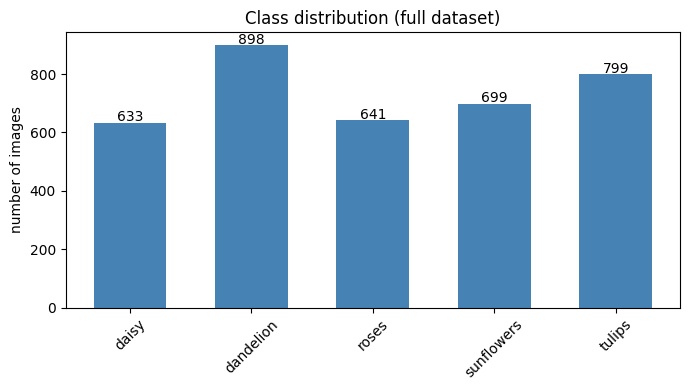

Total: 3670
Largest: dandelion = 898
Smallest: daisy = 633
Imbalance ratio: 1.42


In [ ]:
counts = Counter(all_labels)
class_counts = [counts[i] for i in range(len(class_names))]

plt.figure(figsize=(7, 4))
bars = plt.bar(class_names, class_counts, color="steelblue", width=0.6)
plt.title("Class distribution (full dataset)")
plt.ylabel("number of images")
plt.xticks(rotation=45)
#count on top of each bar
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2, count + 5, str(count), ha="center")
plt.tight_layout()
plt.show()

print("Total:", sum(class_counts))
print("Largest:", class_names[class_counts.index(max(class_counts))], "=", max(class_counts))
print("Smallest:", class_names[class_counts.index(min(class_counts))], "=", min(class_counts))
print(f"Imbalance ratio: {max(class_counts)/min(class_counts):.2f}")

#### Sample Images

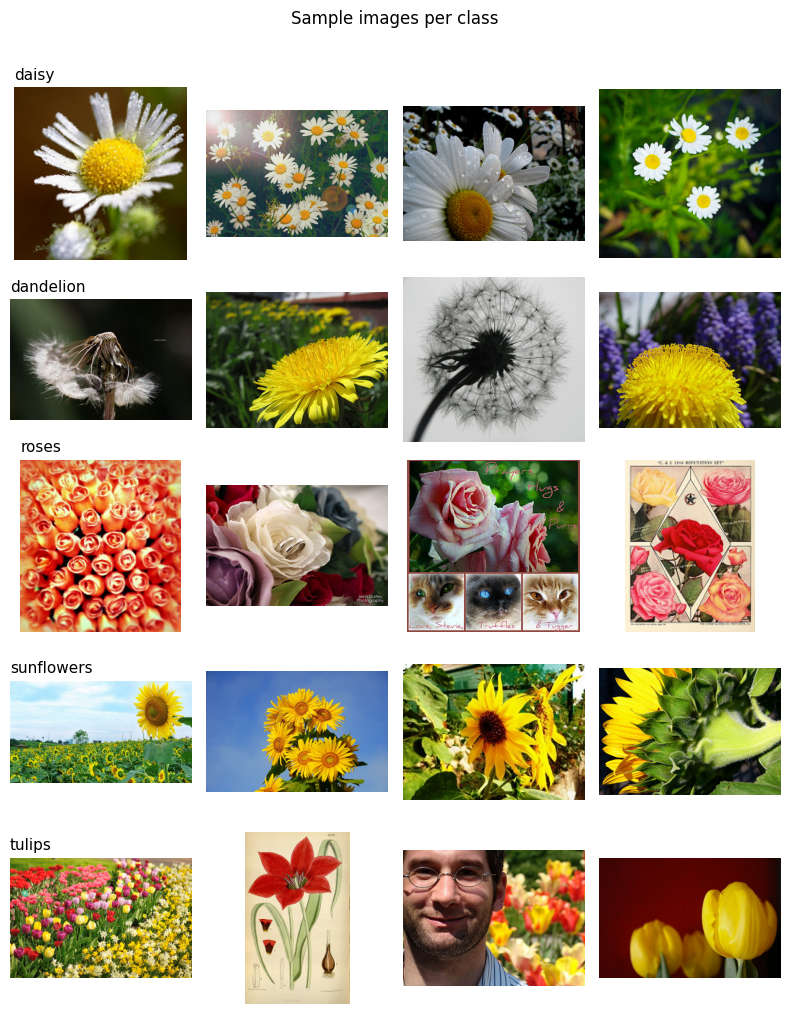

In [ ]:
samples_per_class = 4
plt.figure(figsize=(samples_per_class * 2, len(class_names) * 2))

for row, name in enumerate(class_names):
    class_paths = [p for p, lab in zip(all_paths, all_labels) if lab == row]
    chosen = random.sample(class_paths, samples_per_class)
    for col, path in enumerate(chosen):
        ax = plt.subplot(len(class_names), samples_per_class, row * samples_per_class + col + 1)
        ax.imshow(mpimg.imread(path))
        ax.axis("off")
        if col == 0:
            ax.set_title(name, loc="left", fontsize=11)

plt.suptitle("Sample images per class", y=1.01)
plt.tight_layout()
plt.show()

#### Image Size Variability

In [ ]:
sample = random.sample(all_paths, 300)
widths, heights = [], []
for p in sample:
    with Image.open(p) as img:
        widths.append(img.width)
        heights.append(img.height)

print(f"Sampled {len(sample)} images")
print(f"Width = min: {min(widths)}, max: {max(widths)}, mean: {sum(widths)//len(widths)}")
print(f"Height = min: {min(heights)}, max: {max(heights)}, mean: {sum(heights)//len(heights)}")
print(f"\nImages come in varying sizes - Resize all to {IMG_SIZE}x{IMG_SIZE} for a uniform input.")

Sampled 300 images
Width = min: 157, max: 500, mean: 373
Height = min: 211, max: 442, mean: 277

Images come in varying sizes - Resize all to 160x160 for a uniform input.


#### Split into 70 | 15 | 15

In [ ]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=SEED
)

print("train:", len(train_paths))
print("val:  ", len(val_paths))
print("test: ", len(test_paths))

train: 2569
val:   550
test:  551


#### Check Balance and Leakage

In [ ]:
assert set(train_paths).isdisjoint(val_paths)
assert set(train_paths).isdisjoint(test_paths)
assert set(val_paths).isdisjoint(test_paths)

for split_name, labels in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    counts = Counter(labels)
    print(split_name, {class_names[k]: counts[k] for k in range(len(class_names))})

train {'daisy': 443, 'dandelion': 629, 'roses': 449, 'sunflowers': 489, 'tulips': 559}
val {'daisy': 95, 'dandelion': 134, 'roses': 96, 'sunflowers': 105, 'tulips': 120}
test {'daisy': 95, 'dandelion': 135, 'roses': 96, 'sunflowers': 105, 'tulips': 120}


#### Data Loading (i/p) Pipeline

In [ ]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img, label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths,   val_labels)
test_ds  = make_dataset(test_paths,  test_labels)

In [ ]:
images, labels = next(iter(train_ds))
print("image batch shape:", images.shape)
print("label batch shape:", labels.shape)
print("pixel min/max:", float(tf.reduce_min(images)), float(tf.reduce_max(images)))

image batch shape: (32, 160, 160, 3)
label batch shape: (32,)
pixel min/max: 0.0 255.0


#### Model:1 Custom CNN

In [ ]:
model_a = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Rescaling(1./255),                       # normalization for this model: 0-255 -> 0-1

    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax"),
])

model_a.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_a.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model 1 Training
callbacks_a = [
    callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    callbacks.ModelCheckpoint("model_a_best.keras", monitor="val_loss", save_best_only=True),
]

history_a = model_a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_a,
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.3643 - loss: 1.4323 - val_accuracy: 0.4273 - val_loss: 1.3364 - learning_rate: 0.0010
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.4729 - loss: 1.2335 - val_accuracy: 0.4636 - val_loss: 1.1756 - learning_rate: 0.0010
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.5204 - loss: 1.1435 - val_accuracy: 0.5345 - val_loss: 1.1157 - learning_rate: 0.0010
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.5430 - loss: 1.0886 - val_accuracy: 0.5764 - val_loss: 1.0119 - learning_rate: 0.0010
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.5827 - loss: 1.0311 - val_accuracy: 0.6073 - val_loss: 0.9626 - learning_rate: 0.0010
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.6076 - loss: 0.9758 - val_accuracy: 0.6036 - val_loss: 0.9421 - learning_rate: 0.0010
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.6142 - loss: 0.9663 - val_a

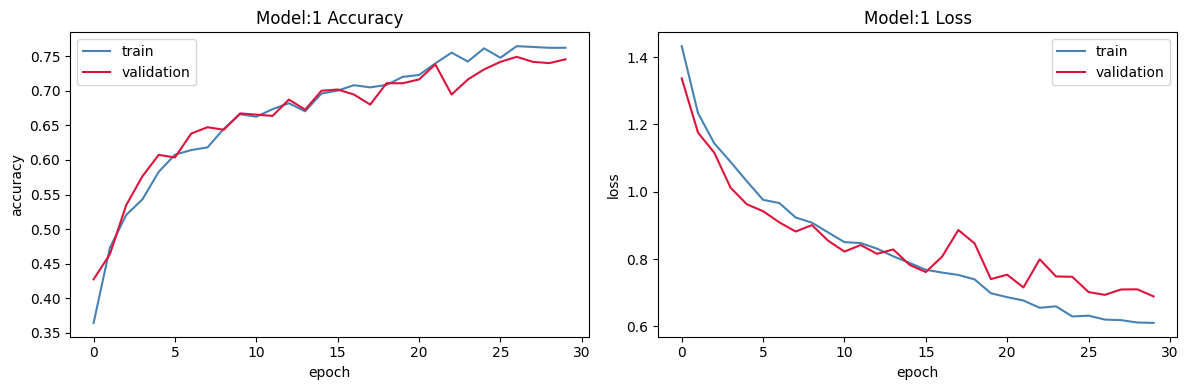

In [ ]:
hist = history_a.history

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(hist["accuracy"], label="train", color="steelblue")
plt.plot(hist["val_accuracy"], label="validation", color="crimson")
plt.title("Model:1 Accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(hist["loss"], label="train", color="steelblue")
plt.plot(hist["val_loss"], label="validation", color="crimson")
plt.title("Model:1 Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.tight_layout()
plt.show()

#### Model:2 Transfer Learning (frozen MobileNetV2)

In [ ]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = preprocess_input(inputs)          # MobileNetV2's OWN normalization: 0-255 -> -1..+1
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model_b = models.Model(inputs, outputs)

model_b.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_b.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Model 2 training
callbacks_b = [
    callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    callbacks.ModelCheckpoint("model_b_best.keras", monitor="val_loss", save_best_only=True),
]

history_b = model_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_b,
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 51s 413ms/step - accuracy: 0.6742 - loss: 0.8914 - val_accuracy: 0.8309 - val_loss: 0.5128 - learning_rate: 0.0010
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.8295 - loss: 0.4540 - val_accuracy: 0.8545 - val_loss: 0.4137 - learning_rate: 0.0010
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.8762 - loss: 0.3421 - val_accuracy: 0.8709 - val_loss: 0.3861 - learning_rate: 0.0010
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.8961 - loss: 0.2941 - val_accuracy: 0.8800 - val_loss: 0.3565 - learning_rate: 0.0010
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.9112 - loss: 0.2542 - val_accuracy: 0.8873 - val_loss: 0.3569 - learning_rate: 0.0010
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9198 - loss: 0.2271 - val_accuracy: 0.8818 - val_loss: 0.3445 - learning_rate: 0.0010
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.9264 - loss: 0.2047 - val_a

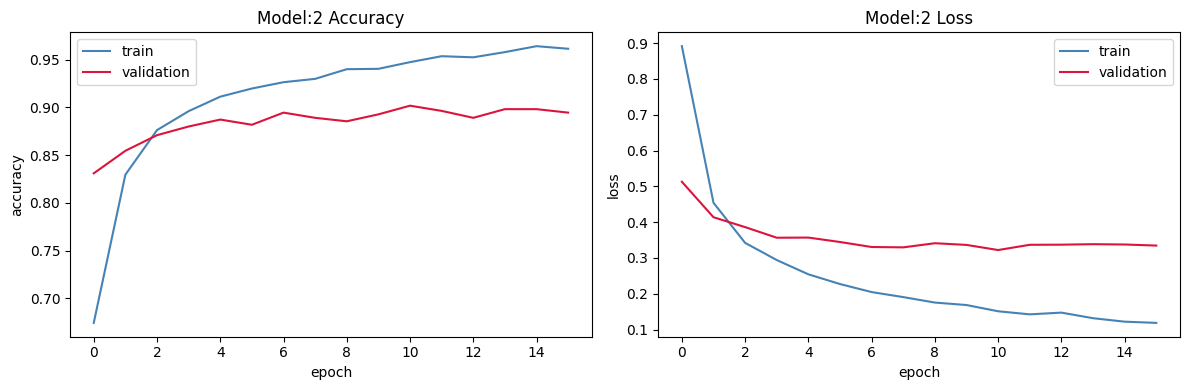

In [ ]:
hist = history_b.history

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(hist["accuracy"], label="train", color="steelblue")
plt.plot(hist["val_accuracy"], label="validation", color="crimson")
plt.title("Model:2 Accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(hist["loss"], label="train", color="steelblue")
plt.plot(hist["val_loss"], label="validation", color="crimson")
plt.title("Model:2 Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.tight_layout()
plt.show()

#### Model:3 Fine-tuned MobileNetV2 (alternative experiment)

In [ ]:
# Continue from the trained Model 2, but now unfreeze the TOP layers of the base
# and train at a very low learning rate, so the pretrained features adapt slightly
# to flowers without being destroyed.

# Unfreeze the base, but keeping the lower (general-purpose) layers frozen
base_model.trainable = True
fine_tune_at = 100                      # freeze layers before #100, fine-tune the rest
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# MUST recompile after changing trainable status, with a LOW learning rate
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),   # 100x smaller than before
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model_b.summary()        # trainable params now much higher than 6,405

callbacks_c = [
    callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    callbacks.ModelCheckpoint("model_c_finetuned.keras", monitor="val_loss", save_best_only=True),
]

history_c = model_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_c,
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 1,867,845 (7.13 MB)

 Non-trainable params: 396,544 (1.51 MB)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 49s 319ms/step - accuracy: 0.8143 - loss: 0.5060 - val_accuracy: 0.9000 - val_loss: 0.3291 - learning_rate: 1.0000e-05
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8649 - loss: 0.3602 - val_accuracy: 0.8945 - val_loss: 0.3347 - learning_rate: 1.0000e-05
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.8992 - loss: 0.2781 - val_accuracy: 0.9018 - val_loss: 0.3330 - learning_rate: 1.0000e-05
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9004 - loss: 0.2581 - val_accuracy: 0.8945 - val_loss: 0.3355 - learning_rate: 1.0000e-05
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9323 - loss: 0.1983 - val_accuracy: 0.8909 - val_loss: 0.3394 - learning_rate: 5.0000e-06
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.9319 - loss: 0.1870 - val_accuracy: 0.8927 - val_loss: 0.3410 - learning_rate: 5.0000e-06


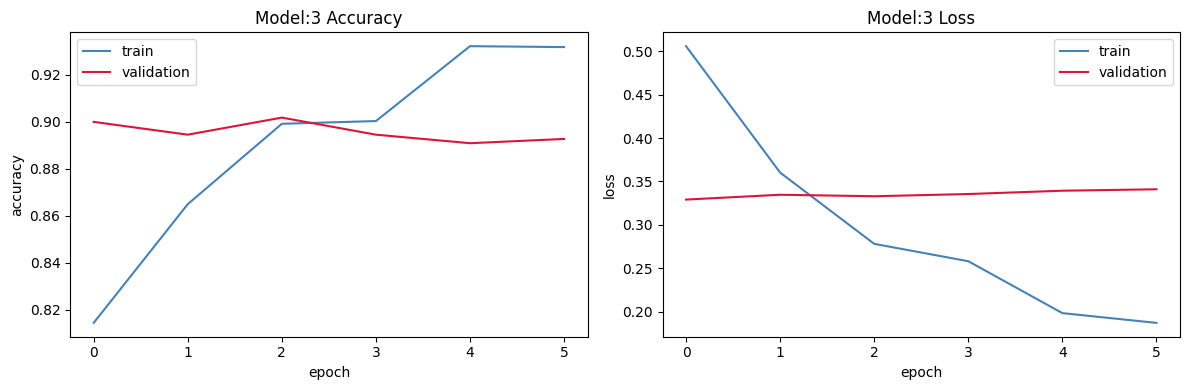

In [ ]:
hist = history_c.history

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(hist["accuracy"], label="train", color="steelblue")
plt.plot(hist["val_accuracy"], label="validation", color="crimson")
plt.title("Model:3 Accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(hist["loss"], label="train", color="steelblue")
plt.plot(hist["val_loss"], label="validation", color="crimson")
plt.title("Model:3 Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.tight_layout()
plt.show()

#### Comparison across models on test data

In [ ]:
# Load the best saved version of each model
best_a = models.load_model("model_a_best.keras")
best_b = models.load_model("model_b_best.keras")
best_c = models.load_model("model_c_finetuned.keras")

# Evaluate on the untouched test set
loss_a, acc_a = best_a.evaluate(test_ds, verbose=0)
loss_b, acc_b = best_b.evaluate(test_ds, verbose=0)
loss_c, acc_c = best_c.evaluate(test_ds, verbose=0)

print(f"Model 1 (custom CNN)                    : test accuracy: {acc_a:.3f}  |  test loss: {loss_a:.3f}")
print(f"Model 2 (frozen MobileNetV2)            : test accuracy: {acc_b:.3f}  |  test loss: {loss_b:.3f}")
print(f"Model 3 (fine-tuned MobileNetV2)        : test accuracy: {acc_c:.3f}  |  test loss: {loss_c:.3f}")

Model 1 (custom CNN)                    : test accuracy: 0.717  |  test loss: 0.747
Model 2 (frozen MobileNetV2)            : test accuracy: 0.900  |  test loss: 0.344
Model 3 (fine-tuned MobileNetV2)        : test accuracy: 0.893  |  test loss: 0.354


#### Confusion Metrics

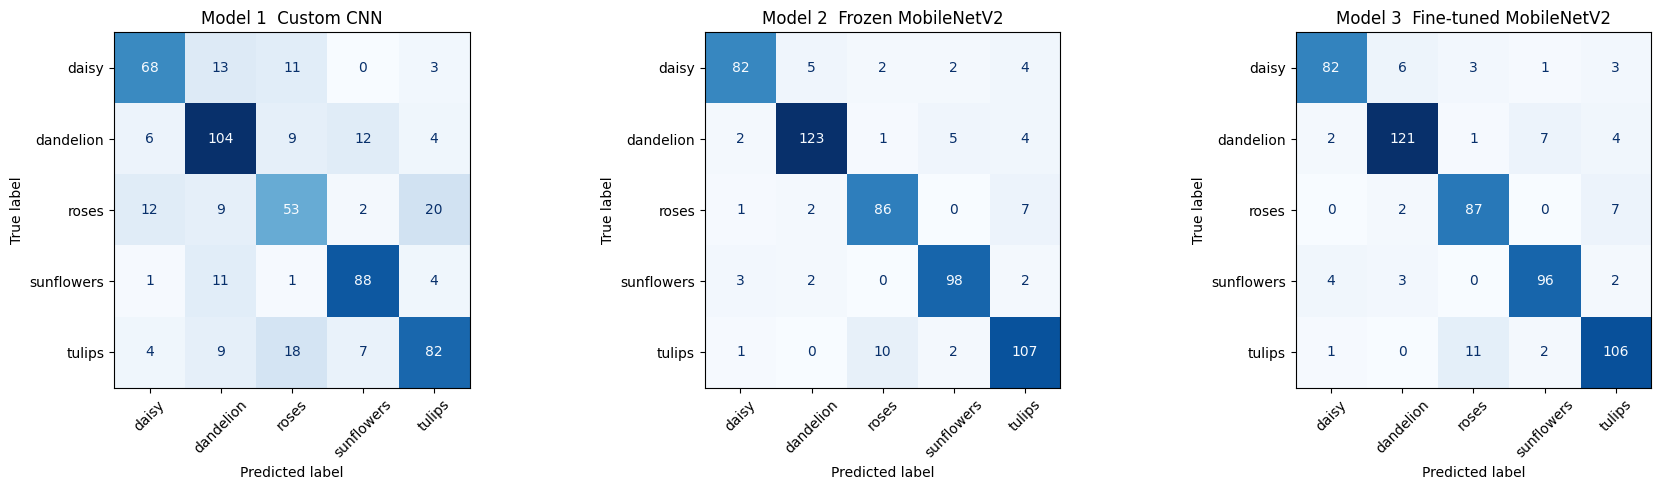

In [ ]:
y_true, y_pred_a, y_pred_b, y_pred_c = [], [], [], []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    y_pred_a.extend(np.argmax(best_a.predict(images, verbose=0), axis=1))
    y_pred_b.extend(np.argmax(best_b.predict(images, verbose=0), axis=1))
    y_pred_c.extend(np.argmax(best_c.predict(images, verbose=0), axis=1))

y_true = np.array(y_true); y_pred_a = np.array(y_pred_a)
y_pred_b = np.array(y_pred_b); y_pred_c = np.array(y_pred_c)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, y_pred, title in [(axes[0], y_pred_a, "Model 1  Custom CNN"),
                          (axes[1], y_pred_b, "Model 2  Frozen MobileNetV2"),
                          (axes[2], y_pred_c, "Model 3  Fine-tuned MobileNetV2")]:
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        cmap="Blues", xticks_rotation=45, ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

#### Evaluation Metrics

In [ ]:
preds = {
    "Model 1 Custom CNN":      y_pred_a,
    "Model 2 Frozen MobileNetV2": y_pred_b,
    "Model 3 Fine-tuned MobileNetV2":      y_pred_c,
}

# Full per-class report for each model
for name, y_pred in preds.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

rows = []
for name, y_pred in preds.items():
    acc = accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
    rows.append({"Model": name, "Accuracy": acc,
                 "Precision (macro)": p, "Recall (macro)": r, "F1 (macro)": f})

summary = pd.DataFrame(rows).set_index("Model").round(3)
print("\nSummary")
print(summary)

Model 1 Custom CNN
              precision    recall  f1-score   support

       daisy      0.747     0.716     0.731        95
   dandelion      0.712     0.770     0.740       135
       roses      0.576     0.552     0.564        96
  sunflowers      0.807     0.838     0.822       105
      tulips      0.726     0.683     0.704       120

    accuracy                          0.717       551
   macro avg      0.714     0.712     0.712       551
weighted avg      0.716     0.717     0.716       551

Model 2 Frozen MobileNetV2
              precision    recall  f1-score   support

       daisy      0.921     0.863     0.891        95
   dandelion      0.932     0.911     0.921       135
       roses      0.869     0.896     0.882        96
  sunflowers      0.916     0.933     0.925       105
      tulips      0.863     0.892     0.877       120

    accuracy                          0.900       551
   macro avg      0.900     0.899     0.899       551
weighted avg      0.901     0.9

#### Validation Accuracy Comparison

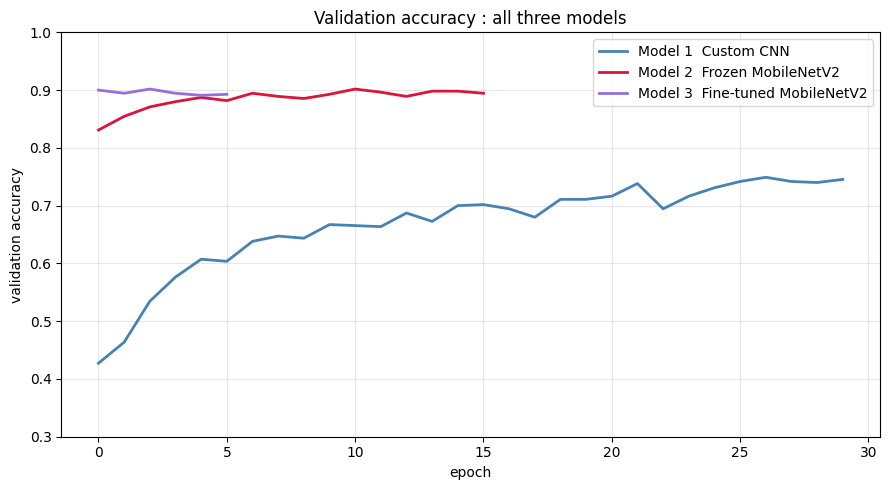

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(history_a.history["val_accuracy"], label="Model 1  Custom CNN", color="steelblue", linewidth=2)
plt.plot(history_b.history["val_accuracy"], label="Model 2  Frozen MobileNetV2", color="crimson", linewidth=2)
plt.plot(history_c.history["val_accuracy"], label="Model 3  Fine-tuned MobileNetV2", color="mediumpurple", linewidth=2)

plt.title("Validation accuracy : all three models")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0.3, 1.0)
plt.tight_layout()
plt.show()

### Misclassified Images

Model 2 misclassified 55 of 551 test images.


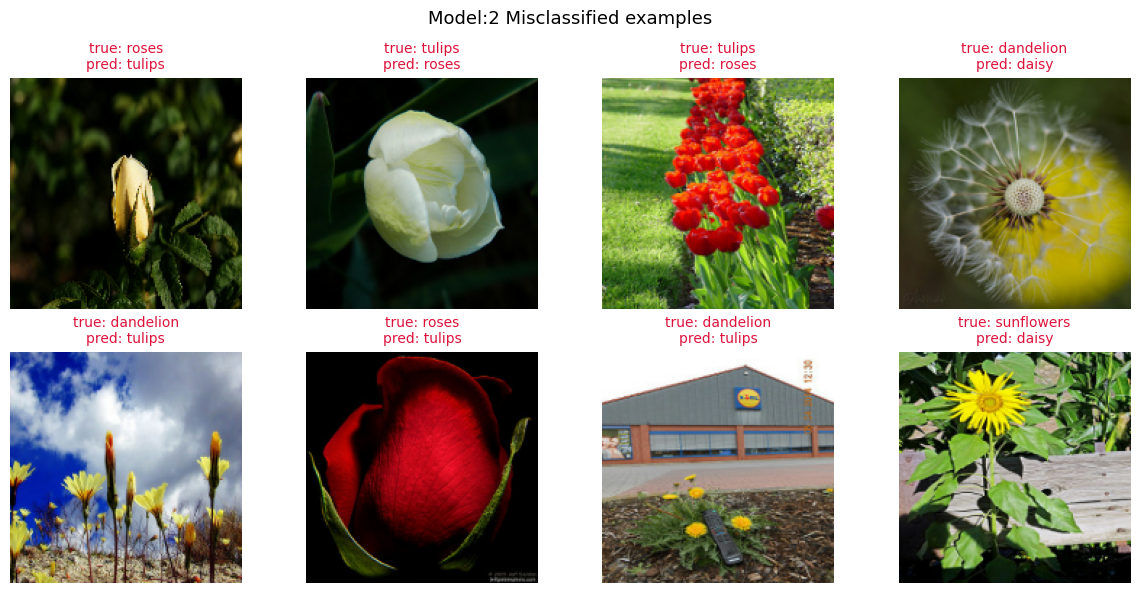

In [ ]:
best_b = models.load_model("model_b_best.keras")

# Single pass: collect images, true labels, predictions - all aligned
mis_images, mis_true, mis_pred = [], [], []
for images, labels in test_ds:
    preds = np.argmax(best_b.predict(images, verbose=0), axis=1)
    labels = labels.numpy()
    for img, true_lab, pred_lab in zip(images, labels, preds):
        if true_lab != pred_lab:                     # keep only the mistakes
            mis_images.append(img.numpy().astype("uint8"))
            mis_true.append(true_lab)
            mis_pred.append(pred_lab)

print(f"Model 2 misclassified {len(mis_images)} of 551 test images.")

# Show the first 8 misclassified examples
n = min(8, len(mis_images))
plt.figure(figsize=(12, 6))
for i in range(n):
    plt.subplot(2, 4, i + 1)
    plt.imshow(mis_images[i])
    plt.axis("off")
    plt.title(f"true: {class_names[mis_true[i]]}\npred: {class_names[mis_pred[i]]}",
              fontsize=10, color="crimson")
plt.suptitle("Model:2 Misclassified examples", fontsize=13)
plt.tight_layout()
plt.show()

#### Model Explainability (GradCAM)

In [ ]:
best_b = models.load_model("model_b_best.keras")

base_model_inner = None
for layer in best_b.layers:
    if isinstance(layer, tf.keras.Model):
        base_model_inner = layer
        break
print("Feature extractor:", base_model_inner.name)

last_conv = None
for layer in reversed(base_model_inner.layers):
    if len(layer.output.shape) == 4:        # 4D output = a conv/feature-map layer
        last_conv = layer.name
        break
print("Last conv layer:", last_conv)


grad_model = tf.keras.models.Model(
    inputs=base_model_inner.input,
    outputs=[base_model_inner.get_layer(last_conv).output, base_model_inner.output]
)

def apply_head(features):
    x = features
    started = False
    for layer in best_b.layers:
        if isinstance(layer, tf.keras.Model):   # the base itself
            started = True
            continue
        if started:
            x = layer(x)
    return x

def make_gradcam_heatmap(img_array, pred_index=None):
    """img_array: (1,160,160,3), raw 0-255."""

    x = preprocess_input(img_array.copy())
    with tf.GradientTape() as tape:
        conv_out, base_out = grad_model(x)
        preds = apply_head(base_out)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

Feature extractor: mobilenetv2_1.00_160
Last conv layer: out_relu


2 correct, 2 confused examples


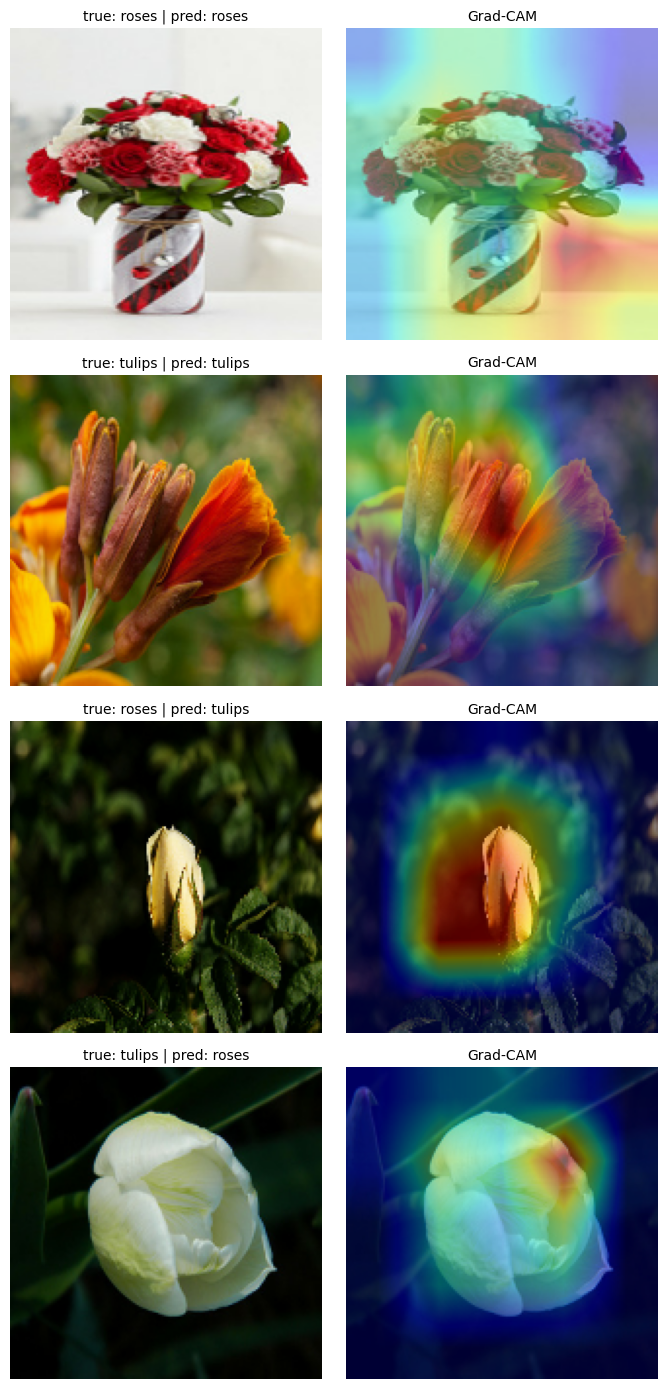

In [ ]:
rose_idx  = class_names.index("roses")
tulip_idx = class_names.index("tulips")

correct_examples, confused_examples = [], []
for images, labels in test_ds:
    preds = np.argmax(best_b.predict(images, verbose=0), axis=1)
    labels = labels.numpy()
    for img, t, p in zip(images.numpy(), labels, preds):
        if t == p and t in (rose_idx, tulip_idx) and len(correct_examples) < 2:
            correct_examples.append((img, t, p))            # correctly classified rose/tulip
        elif t != p and {t, p} == {rose_idx, tulip_idx} and len(confused_examples) < 2:
            confused_examples.append((img, t, p))           # rose<->tulip confusion
    if len(correct_examples) >= 2 and len(confused_examples) >= 2:
        break

examples = correct_examples + confused_examples
print(f"{len(correct_examples)} correct, {len(confused_examples)} confused examples")

plt.figure(figsize=(7, 3.5 * len(examples)))
for row, (img, t, p) in enumerate(examples):
    arr = np.expand_dims(img, axis=0)                       # (1,160,160,3), raw 0-255
    heatmap, _ = make_gradcam_heatmap(arr)
    heatmap_big = tf.image.resize(heatmap[..., np.newaxis], (IMG_SIZE, IMG_SIZE)).numpy().squeeze()

    ax1 = plt.subplot(len(examples), 2, row * 2 + 1)
    ax1.imshow(img.astype("uint8"))
    ax1.set_title(f"true: {class_names[t]} | pred: {class_names[p]}", fontsize=10)
    ax1.axis("off")

    ax2 = plt.subplot(len(examples), 2, row * 2 + 2)
    ax2.imshow(img.astype("uint8"))
    ax2.imshow(heatmap_big, cmap="jet", alpha=0.4)          # heatmap overlaid
    ax2.set_title("Grad-CAM", fontsize=10)
    ax2.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
os.makedirs('/content/drive/MyDrive/FDL_Project', exist_ok=True)
for f in ["model_a_best.keras", "model_b_best.keras", "model_c_finetuned.keras"]:
    shutil.copy(f, f'/content/drive/MyDrive/FDL_Project/{f}')
print("All three models saved to Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All three models saved to Drive.
